# Indicadores Técnicos de Mercado

* Universidad de Chile - ``Aplicaciones Financieras con Machine Learning``

* Franco Mansilla Ibáñez (www.francomansilla.com)

In [1]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=20829e0ad3426e9885dc639496a1aa096e46f859a3d624a0dccb58ed0584bdf5
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta


# 1. Librerías

In [2]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt

# 2. Carga de Datos

* Datos historicos de la acción de ``Falabella``


In [3]:
start = '2020-01-01'
end = '2022-12-31'

df = yf.download('FALABELLA.SN', start= start, end = end)
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,3350.000000,3379.000000,3241.000000,3350.000000,3231.993408,252306
2020-01-03,3350.000000,3378.899902,3211.000000,3350.000000,3248.478027,281213
2020-01-06,3390.000000,3394.000000,3299.899902,3390.000000,3287.265869,113081
2020-01-07,3450.000000,3495.000000,3380.000000,3450.000000,3345.447510,273437
2020-01-08,3455.899902,3520.000000,3365.100098,3455.899902,3351.168945,317642
...,...,...,...,...,...,...
2022-12-26,1655.000000,1660.000000,1612.099976,1655.000000,1655.000000,560891
2022-12-27,1648.599976,1654.000000,1611.000000,1648.599976,1648.599976,846540
2022-12-28,1649.000000,1649.000000,1620.199951,1649.000000,1649.000000,1299750


# 3. Indicadores Técnicos de Mercado

Los indicadores técnicos de mercado son herramientas utilizadas por los traders e inversores para evaluar la dirección probable de los precios de los activos y para tomar decisiones de trading basadas en patrones de comportamiento pasado y presente del precio, volumen, y, en algunos casos, interés abierto.

Se clasifican en:
1. **Indicadores de Tendencia**.  ayudan a identificar y seguir la dirección de las tendencias del mercado.
2. **Indicadores de Momentum**. ayudan a medir la velocidad de los cambios de precio para determinar la fuerza detrás de los movimientos del mercado.
3. **Indicadores de Volumen**. utilizan el volumen de transacciones para confirmar tendencias o advertir sobre posibles reversiones.
4. **Indicadores de Volatilidad**. miden la variabilidad de los precios del mercado para evaluar las fluctuaciones y la incertidumbre.
5. **Indicadores de Soporte y Resistencia**. ayudan a identificar áreas clave donde los precios de los activos podrían detenerse y posiblemente revertirse






# Ind. 1. Media Móvil

Calcula el promedio de precios de cierre de un activo durante un período específico. **Identificar la dirección de la tendencia**. Una SMA creciente indica una tendencia alcista, mientras que una decreciente señala una tendencia bajista. Usualmente se usa 20, 50, 200 días. La de 200 días es popular para determinar tendencias a largo plazo.

In [8]:
# Media Móvil de 5 días
df['MMS_5d'] = df['Close'].rolling(window = 5).mean()

# Media Móvil de 5 días
df['MMS_20d'] = df['Close'].rolling(window = 20).mean()

df

,Open,High,Low,Close,Adj Close,Volume,MMS_5d,MMS_20d
Date,,,,,,,,
2020-01-02,3350.000000,3379.000000,3241.000000,3350.000000,3231.993164,252306,NaN,NaN
2020-01-03,3350.000000,3378.899902,3211.000000,3350.000000,3248.478027,281213,NaN,NaN
2020-01-06,3390.000000,3394.000000,3299.899902,3390.000000,3287.265869,113081,NaN,NaN
2020-01-07,3450.000000,3495.000000,3380.000000,3450.000000,3345.447754,273437,NaN,NaN
2020-01-08,3455.899902,3520.000000,3365.100098,3455.899902,3351.168701,317642,3399.179980,NaN
...,...,...,...,...,...,...,...,...
2022-12-26,1655.000000,1660.000000,1612.099976,1655.000000,1655.000000,560891,1608.419995,1577.284998
2022-12-27,1648.599976,1654.000000,1611.000000,1648.599976,1648.599976,846540,1627.719995,1583.794995
2022-12-28,1649.000000,1649.000000,1620.199951,1649.000000,1649.000000,1299750,1641.519995,1588.494995


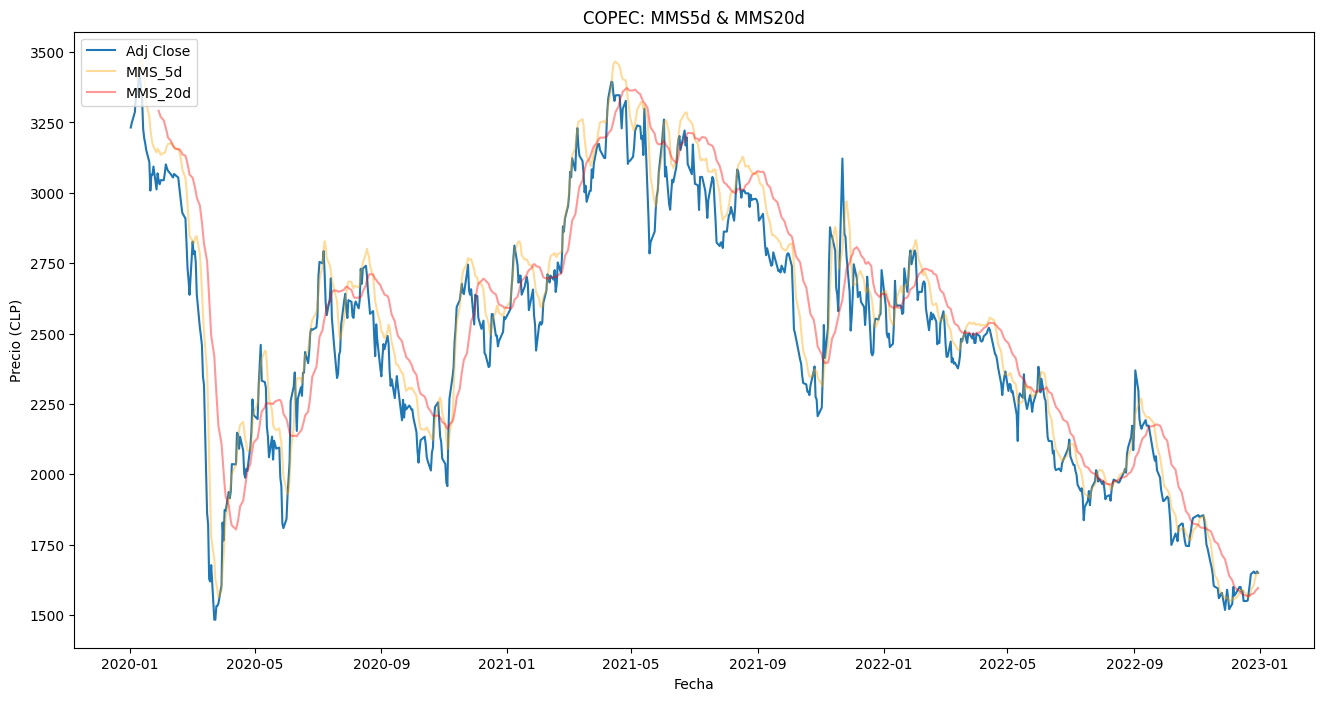

In [9]:
plt.figure(figsize = (16,8))
plt.title('COPEC: MMS5d & MMS20d')
plt.plot(df['Adj Close'])
plt.plot(df['MMS_5d'], color = 'orange', alpha = 0.4)
plt.plot(df['MMS_20d'], color = 'red', alpha = 0.4)
plt.xlabel('Fecha')
plt.ylabel('Precio (CLP)')
plt.legend(['Adj Close', 'MMS_5d', 'MMS_20d'], loc = 'upper left')

# Ind. 2. Media Móvil Exponencial

Similar a la SMA pero da **más peso a los datos más recientes**, respondiendo más rápidamente a los cambios de precios. Identificar tendencias y puntos de reversión más rápidamente que la SMA. Usualmente 12, 26 días (usadas en el cálculo del MACD), 9 días como señal de seguimiento.

In [10]:
# Media Movil Exponencial de 5 días (MME_5d)
df['MME_5d'] = df['Adj Close'].ewm(span = 5, adjust = False). mean()

# Media Movil Exponencial de 5 días (MME_5d)
df['MME_20d'] = df['Adj Close'].ewm(span = 20, adjust = False). mean()

df

,Open,High,Low,Close,Adj Close,Volume,MMS_5d,MMS_20d,MME_5d,MME_20d
Date,,,,,,,,,,
2020-01-02,3350.000000,3379.000000,3241.000000,3350.000000,3231.993164,252306,NaN,NaN,3231.993164,3231.993164
2020-01-03,3350.000000,3378.899902,3211.000000,3350.000000,3248.478027,281213,NaN,NaN,3237.488118,3233.563151
2020-01-06,3390.000000,3394.000000,3299.899902,3390.000000,3287.265869,113081,NaN,NaN,3254.080702,3238.677696
2020-01-07,3450.000000,3495.000000,3380.000000,3450.000000,3345.447754,273437,NaN,NaN,3284.536386,3248.846273
2020-01-08,3455.899902,3520.000000,3365.100098,3455.899902,3351.168701,317642,3399.179980,NaN,3306.747158,3258.591266
...,...,...,...,...,...,...,...,...,...,...
2022-12-26,1655.000000,1660.000000,1612.099976,1655.000000,1655.000000,560891,1608.419995,1577.284998,1620.208064,1601.924876
2022-12-27,1648.599976,1654.000000,1611.000000,1648.599976,1648.599976,846540,1627.719995,1583.794995,1629.672035,1606.370124
2022-12-28,1649.000000,1649.000000,1620.199951,1649.000000,1649.000000,1299750,1641.519995,1588.494995,1636.114690,1610.430112


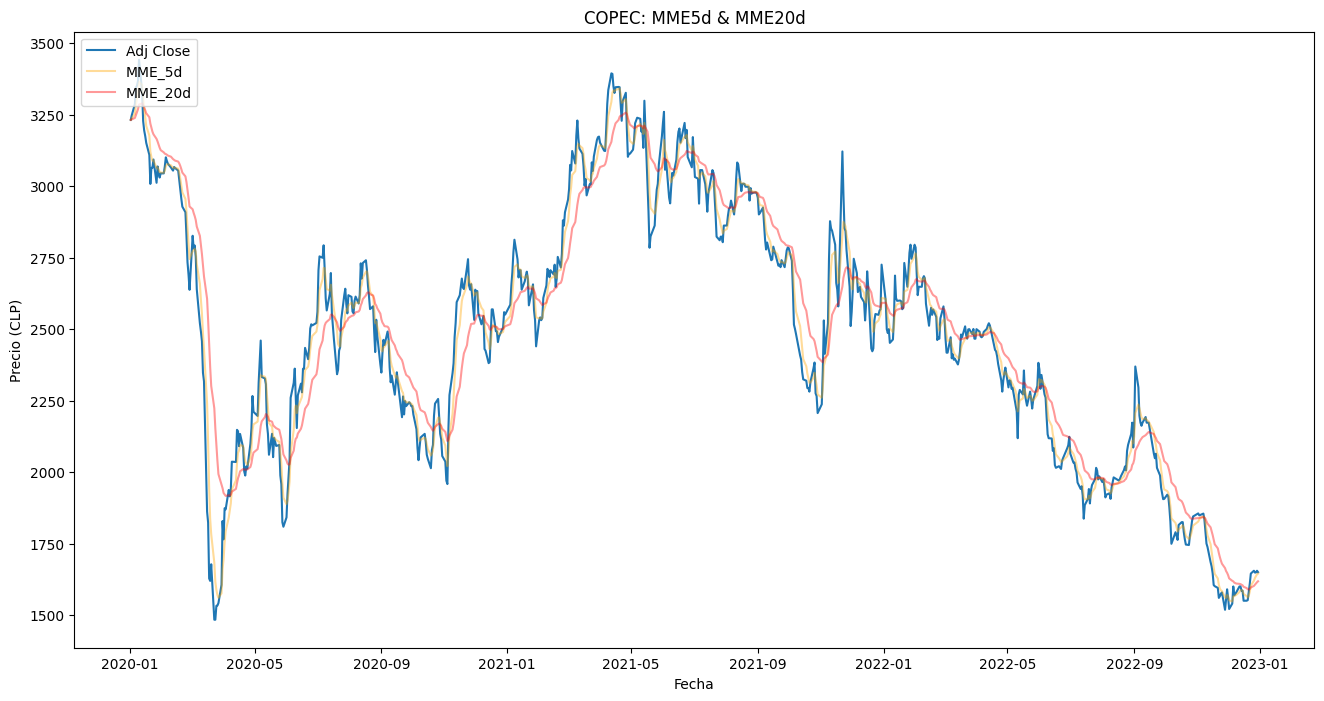

In [12]:
plt.figure(figsize = (16,8))
plt.title('COPEC: MME5d & MME20d')
plt.plot(df['Adj Close'])
plt.plot(df['MME_5d'], color = 'orange', alpha = 0.4)
plt.plot(df['MME_20d'], color = 'red', alpha = 0.4)
plt.xlabel('Fecha')
plt.ylabel('Precio (CLP)')
plt.legend(['Adj Close', 'MME_5d', 'MME_20d'], loc = 'upper left')

# Ind. 3. Bandas de Bollinger

Consiste en una SMA (generalmente de 20 días) con dos bandas a una desviación estándar por encima y por debajo. Determinar niveles de sobrecompra y sobreventa. Si el precio toca la banda superior, podría considerarse sobrecomprado; si toca la inferior, sobrevendido. Se configura 20 días para la media y 2 desviaciones estándar para las bandas.

In [13]:
# Bandas de Bollinger

# Libreria de Análisis Técnico
import ta

bb = ta.volatility.BollingerBands(close = df['Close'], window = 20, window_dev = 2)
# Ventana de media movil 20 días (window = 20)
# Desviaciones estandar para calcular las bandas 2 (window_dev = 2)

df['BOL_MED'] = bb.bollinger_mavg()
df['BOL_SUP'] = bb.bollinger_hband()
df['BOL_INF'] = bb.bollinger_lband()

df

,Open,High,Low,Close,Adj Close,Volume,MMS_5d,MMS_20d,MME_5d,MME_20d,BOL_MED,BOL_SUP,BOL_INF
Date,,,,,,,,,,,,,
2020-01-02,3350.000000,3379.000000,3241.000000,3350.000000,3231.993164,252306,NaN,NaN,3231.993164,3231.993164,NaN,NaN,NaN
2020-01-03,3350.000000,3378.899902,3211.000000,3350.000000,3248.478027,281213,NaN,NaN,3237.488118,3233.563151,NaN,NaN,NaN
2020-01-06,3390.000000,3394.000000,3299.899902,3390.000000,3287.265869,113081,NaN,NaN,3254.080702,3238.677696,NaN,NaN,NaN
2020-01-07,3450.000000,3495.000000,3380.000000,3450.000000,3345.447754,273437,NaN,NaN,3284.536386,3248.846273,NaN,NaN,NaN
2020-01-08,3455.899902,3520.000000,3365.100098,3455.899902,3351.168701,317642,3399.179980,NaN,3306.747158,3258.591266,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-26,1655.000000,1660.000000,1612.099976,1655.000000,1655.000000,560891,1608.419995,1577.284998,1620.208064,1601.924876,1577.284998,1647.334648,1507.235347
2022-12-27,1648.599976,1654.000000,1611.000000,1648.599976,1648.599976,846540,1627.719995,1583.794995,1629.672035,1606.370124,1583.794995,1654.936478,1512.653513
2022-12-28,1649.000000,1649.000000,1620.199951,1649.000000,1649.000000,1299750,1641.519995,1588.494995,1636.114690,1610.430112,1588.494995,1663.709746,1513.280245


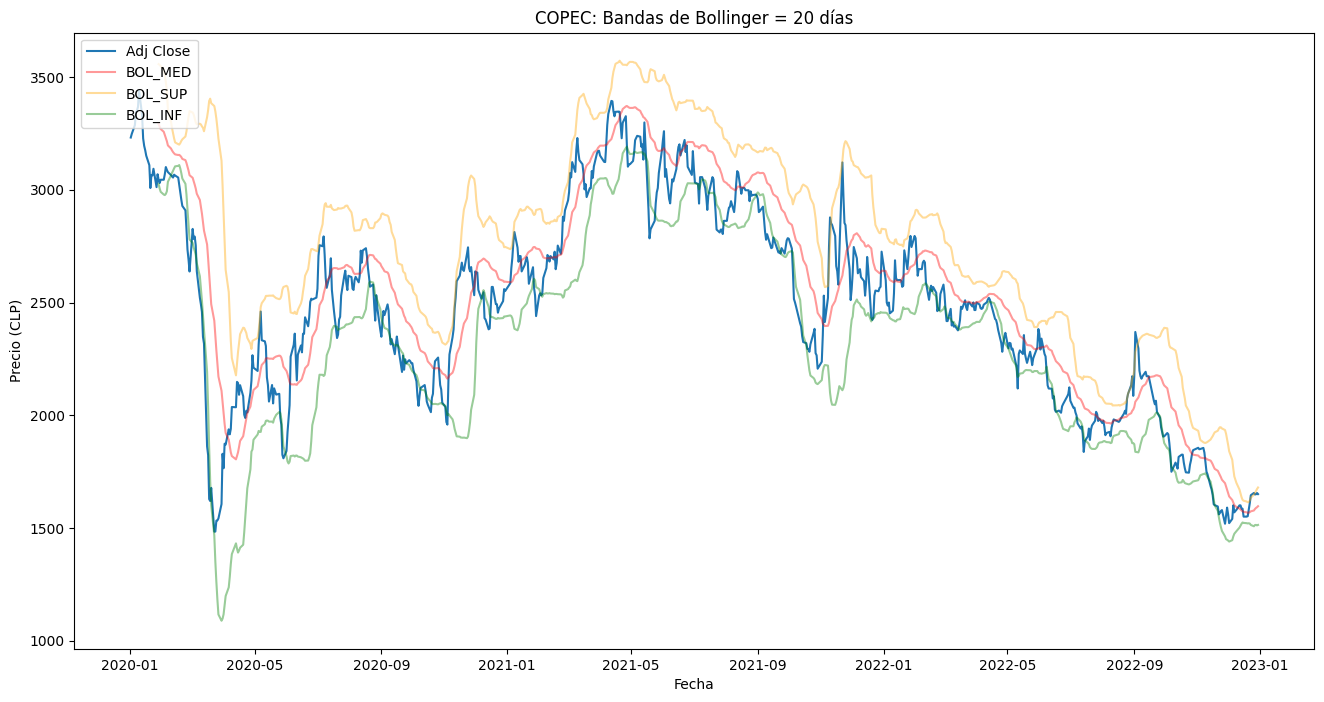

In [14]:
plt.figure(figsize = (16,8))
plt.title('COPEC: Bandas de Bollinger = 20 días')
plt.plot(df['Adj Close'])
plt.plot(df['BOL_MED'], color = 'red', alpha = 0.4)
plt.plot(df['BOL_SUP'], color = 'orange', alpha = 0.4)
plt.plot(df['BOL_INF'], color = 'green', alpha = 0.4)
plt.xlabel('Fecha')
plt.ylabel('Precio (CLP)')
plt.legend(['Adj Close', 'BOL_MED', 'BOL_SUP', 'BOL_INF'], loc = 'upper left')

# Ind. 4. Oscilarios (Media Móvil de Convergencia-Divergencia)

Utiliza EMAs para mostrar la **relación entre dos medias móviles de un precio**. Se usa Línea MACD (diferencia entre EMA de 26 y 12 días), Línea de señal (EMA de 9 días del MACD), y histograma (diferencia entre MACD y línea de señal). Identificar la dirección del momentum y los cambios en él. Cruces de la línea MACD y la línea de señal indican posibles puntos de entrada o salida.

In [15]:
# Osciladores: Media Móvil de Convergencia-Divergencia (MACD)

df['MACD'] = ta.trend.MACD(close = df['Close'], window_fast = 12, window_slow = 26).macd()
# Media movil de corto plazo de 12 dias (window_fast = 12)
# Media movil de largo plazo de 26 dias (window_slow = 26)

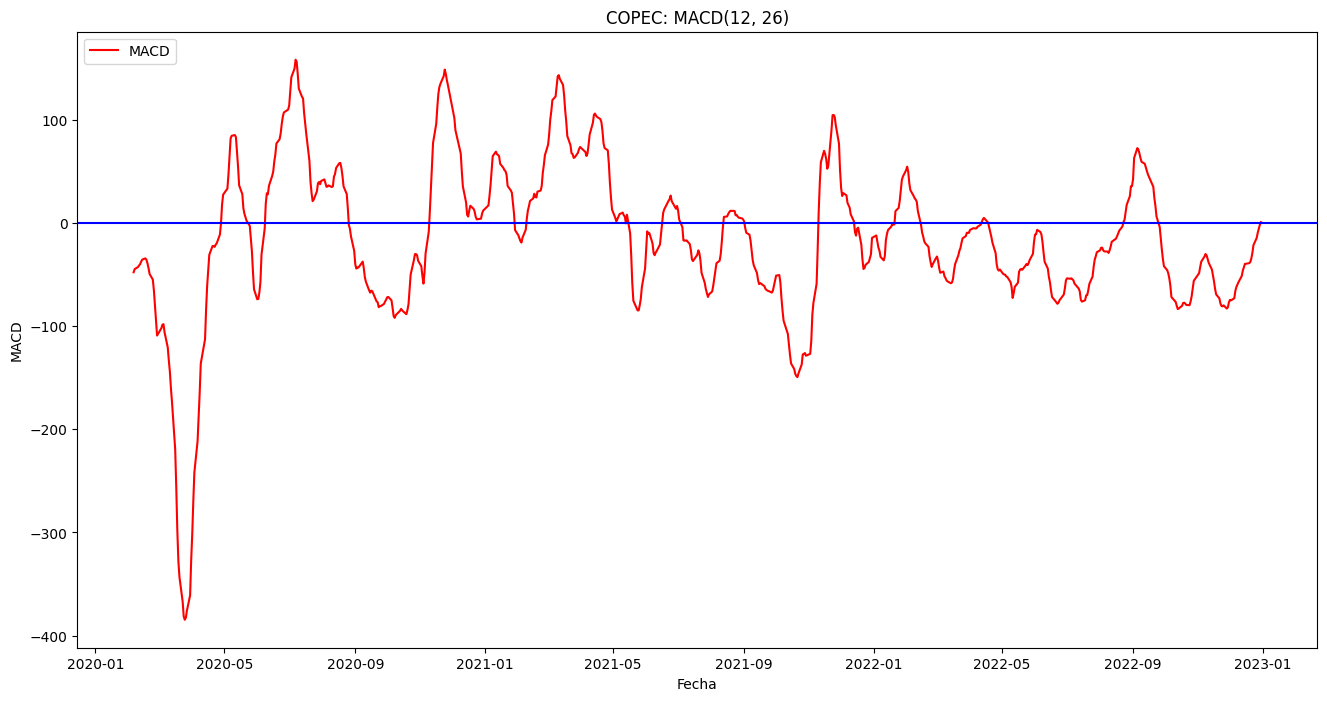

In [16]:
plt.figure(figsize = (16,8))
plt.title('COPEC: MACD(12, 26)')
plt.plot(df['MACD'], color = 'red')
plt.xlabel('Fecha')
plt.ylabel('MACD')
plt.legend(['MACD'], loc = 'upper left')
plt.axhline(y=0, color = 'blue')

# Ind. 5. Retrocesos de Fibonacci

La herramienta de retroceso de Fibonacci se basa en la idea de que los mercados experimentan una retracción o corrección después de un movimiento significativo en una dirección, y que esta retracción tiende a detenerse cerca de los niveles proporcionados por las proporciones de Fibonacci.

•	**23.6%** - Aunque es el nivel más débil, puede ofrecer algún soporte o resistencia.\
•	**38.2%** +- Considerado un nivel de retracción moderado.\
•	**61.8%** (también conocido como “la proporción áurea”) - Es el nivel de retracción más observado y respetado.\
•	**78.6%** - Un nivel más profundo que puede indicar una retracción significativa antes de continuar la tendencia.\
•	**100%** - Completa retracción a la posición original antes del movimiento del precio.

In [17]:
# Retrocesos de Fibonacci

max_p = df['Close'].max()
min_p = df['Close'].min()

dif_p = max_p - min_p


r_fibo = np.array([0.236, 0.382, 0.5, 0.618])
levels = max_p - dif_p*r_fibo

levels

array([3070.54240576, 2773.92880933, 2534.20001221, 2294.47121509])

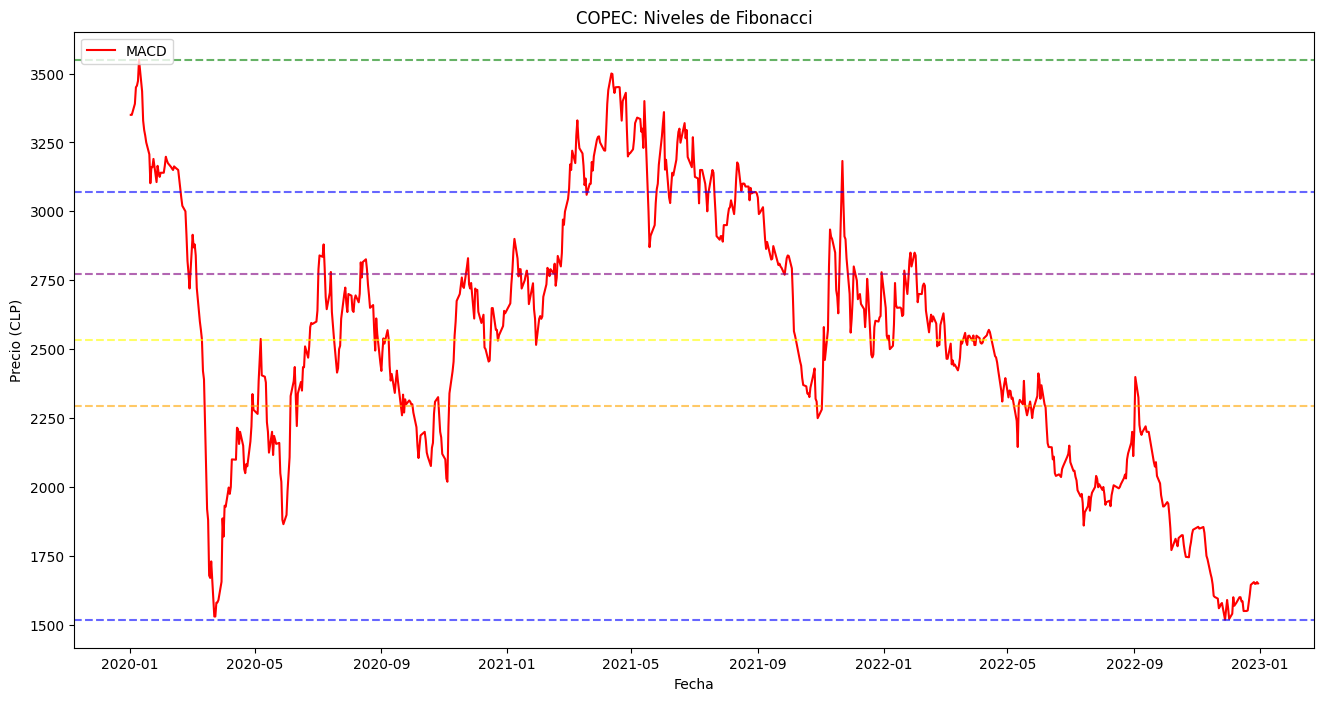

In [19]:
plt.figure(figsize = (16,8))
plt.title('COPEC: Niveles de Fibonacci')
plt.plot(df['Close'], color = 'red')
plt.xlabel('Fecha')
plt.ylabel('Precio (CLP)')
plt.legend(['MACD'], loc = 'upper left')
plt.axhline(y=max_p, color = 'green', linestyle = '--', alpha = 0.6)
plt.axhline(y=levels[0], color = 'blue', linestyle = '--', alpha = 0.6)
plt.axhline(y=levels[1], color = 'purple', linestyle = '--', alpha = 0.6)
plt.axhline(y=levels[2], color = 'yellow', linestyle = '--', alpha = 0.6)
plt.axhline(y=levels[3], color = 'orange', linestyle = '--', alpha = 0.6)
plt.axhline(y=min_p, color = 'blue', linestyle = '--', alpha = 0.6)
